# Limpieza de datos — etenphaseinverter (microinversores Enphase)

## Índice del proceso

- **Bloque 0 — Imports**
- **Bloque 1 — Carga**
  - 1.1 — Lectura y combinación de archivos
  - 1.2 — Eliminación de duplicados por solape de descargas
- **Bloque 2 — Conversión de tipos y selección de columnas**
- **Bloque 3 — Descripción estadística**
  - 3.1 Info
  - 3.2 — Distribución temporal y por entidad
    - Celda A — Registros por día
    - Celda B — Registros por hora del día
    - Celda C — Registros por entity_id
  - 3.3 — Distribución de `energyproducedtoday`
  - 3.4 — Evidencia del reinicio diario del contador
- **Bloque 4 — Limpieza de atípicos**
  - 4.1 — Conversión a numéricos
  - 4.2 — Validación de rangos físicos y descarte de lecturas corruptas
  - 4.3 — Eliminación de filas sin información esencial
- **Bloque 5 — Resample horario: energía incremental con regla de reinicio diario**
  - 5.1 — Contador al cierre de cada hora + cobertura cruda
  - 5.2 — Energía horaria + banderas de calidad
  - 5.3 — Validación: suma horaria contra el total de cada ciclo
- **Bloque 6 — Exportación**

> **Qué es esta fuente.** Una sola entidad, `enphase_monitor`, que agrega todos los
> microinversores del sistema **SFV1_Terraza Juan Pablo II (Bloque 10, 4,9 kWp)**. No hay
> lectura por microinversor ni columna `refplant`: el monitor entrega el total del arreglo.
>
> **Qué alimenta.** `energyproducedtoday` va a IND-08 (IGS), IND-14 (DFV) y KPI 07
> (autosuficiencia). **No alimenta el KPI 06 (PR)**: el arreglo tiene azimut 126° frente a
> los 238–264° del único sensor de irradiancia del campus, así que es otro plano de
> incidencia y un PR calculado con esa irradiancia no tendría significado físico.
>
> **Igual que el Fronius**, `energyproducedtoday` es un contador **diario**: sube durante el
> día y vuelve a cero en el siguiente ciclo. Un delta negativo no es corrupción, es el
> reinicio esperado, y la energía de esa hora es lo acumulado desde el reinicio.

## Bloque 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Bloque 1 — Carga

### 1.1 — Lectura y combinación de archivos

In [2]:
from pathlib import Path

# Cambiar según el formato de los archivos fuente: 'csv' o 'xlsx'
FORMAT = 'csv'

# Solo se ingieren los archivos del monitor Enphase (no los del resto de entidades)
SOURCE_GLOB = 'etenphaseinverter_*'

# Los archivos vienen con estos dos encabezados en español; el resto del
# proyecto los usa con estos nombres
COL_MAP = {
    'Fecha y Hora': 'time_index_colombia',
    'ID Entidad':   'entity_id',
}

# Según el FORMAT de arriba, se arma la lista de archivos y se define cómo leerlos
if FORMAT == 'csv':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.csv'))
    def load(f):
        return pd.read_csv(f, sep=',', low_memory=False)

elif FORMAT == 'xlsx':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.xlsx'))
    def load(f):
        return pd.read_excel(f)

print(f'{len(files)} archivos encontrados:')
for f in files:
    print(' ', f.name)

# Se lee archivo por archivo, se renombran las columnas y se van guardando en una lista
partes = []
for f in files:
    chunk = load(f)
    chunk.rename(columns=COL_MAP, inplace=True)
    partes.append(chunk)

# Todo queda en un solo DataFrame. join='outer' conserva cualquier columna
# aunque no esté en todos los archivos; ignore_index reinicia la numeración de filas
df = pd.concat(partes, join='outer', ignore_index=True)

# Avisar si algún archivo tiene columnas distintas al resto
# (todas las columnas que existen) − (las que están en TODOS) = las que faltan en alguno
col_sets = [set(p.columns) for p in partes]
extra = set.union(*col_sets) - set.intersection(*col_sets)
if extra:
    print('Columnas inconsistentes entre archivos:', extra)

print(f'Shape combinado: {df.shape}')
df.head()

1 archivos encontrados:
  etenphaseinverter_2026-09-06_12-10-36.csv


Shape combinado: (265457, 11)


,entity_id,Tipo Entidad,time_index_colombia,fiware_servicepath,__original_ngsi_entity__,instanceid,timeinstant,currentpowerproduction,energyproducedtoday,energyproducedlastsevendays,energyproducedlifetime
0,enphase_monitor,EnphaseInverter,2026-01-30 19:00:22,/,NaN,urn:ngsi-ld:9b932884-3fcf-44f3-a484-9e1e89eafc84,1769817622000,36,8158,86908,71959304
1,enphase_monitor,EnphaseInverter,2026-01-30 19:01:22,/,NaN,urn:ngsi-ld:2dd669e8-0960-46ef-8ffa-f34266361752,1769817682000,36,8158,86908,71959304
2,enphase_monitor,EnphaseInverter,2026-01-30 19:02:22,/,NaN,urn:ngsi-ld:1e9df6e5-d594-4610-8a30-82617a9fa9f7,1769817742000,36,8158,86908,71959304
3,enphase_monitor,EnphaseInverter,2026-01-30 19:03:22,/,NaN,urn:ngsi-ld:4a1f0a55-b4bb-4109-96d5-c56ca6f7bd25,1769817802000,36,8158,86908,71959304
4,enphase_monitor,EnphaseInverter,2026-01-30 19:04:22,/,NaN,urn:ngsi-ld:48093fbc-59f2-40d1-8611-d16c14073c54,1769817862000,36,8158,86908,71959304


### 1.2 — Eliminación de duplicados por solape de descargas

Las exportaciones de FIWARE se piden por rango de fechas, así que es normal que dos
descargas se solapen y un mismo día entre dos veces.

El resample del Bloque 5 absorbe el duplicado por sí solo —el `last` de un valor repetido
es el mismo valor—, pero **`n_muestras` se duplicaría** y la bandera de cobertura mentiría:
una hora construida con 4 lecturas parecería tener 8. Por eso se deduplica antes de agregar.

In [3]:
## keep='last' hace que, si un mismo instante llegara con valores distintos entre
## dos exportaciones, gane el del archivo más reciente: la lista `files` viene
## ordenada por nombre y los nombres llevan la fecha de exportación.
antes = len(df)
df = df.drop_duplicates(subset=['entity_id', 'time_index_colombia'], keep='last')
print(f'Filas duplicadas eliminadas: {antes - len(df)}  — quedan {len(df)}')

Filas duplicadas eliminadas: 4  — quedan 265453


## Bloque 2 — Conversión de tipos y selección de columnas

In [4]:
# El archivo trae 11 columnas del monitor; de todas ellas solo se conserva la marca de
# tiempo, la entidad y la que alimenta indicadores del proyecto:
#   energyproducedtoday -> IND-08 (IGS), IND-14 (DFV) y KPI 07 (autosuficiencia solar)
#
# energyproducedlifetime se arrastra SOLO hasta el Bloque 4 y no se exporta: no entra en
# ninguna fórmula, pero es el único testigo de si la lectura completa es válida (ver 4.2).
#
# Se descartan a propósito, y no por omisión:
#   currentpowerproduction      -> potencia instantánea; no entra en ninguna fórmula
#   energyproducedlastsevendays -> ventana móvil del propio equipo, redundante con la
#                                  energía horaria que este notebook reconstruye
#   timeinstant                 -> duplica la marca de tiempo del broker
#
# No hay columna refplant como en el Fronius: esta fuente tiene una sola entidad,
# 'enphase_monitor', que corresponde a SFV1_Terraza Juan Pablo II (Bloque 10, 4,9 kWp).
COLS = ['time_index_colombia', 'entity_id', 'energyproducedtoday', 'energyproducedlifetime']
df = df[COLS].copy()

df['time_index_colombia'] = pd.to_datetime(df['time_index_colombia'], utc=False, format='%Y-%m-%d %H:%M:%S')
df['entity_id'] = df['entity_id'].astype('category')

num_cols = ['energyproducedtoday']            # lo que se exporta
aux_cols = ['energyproducedlifetime']         # auxiliar de validación, no se exporta
for col in num_cols + aux_cols:
    # Lo que no se pueda convertir queda como NaN; esas filas se eliminan en el Bloque 4
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

time_index_colombia       datetime64[ns]
entity_id                       category
energyproducedtoday                int64
energyproducedlifetime             int64
dtype: object


## Bloque 3 — Descripción estadística

### 3.1 Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 265453 entries, 0 to 265456
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   time_index_colombia     265453 non-null  datetime64[ns]
 1   entity_id               265453 non-null  category      
 2   energyproducedtoday     265453 non-null  int64         
 3   energyproducedlifetime  265453 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 8.4 MB


In [6]:
df.describe(include='all')

,time_index_colombia,entity_id,energyproducedtoday,energyproducedlifetime
count,265453,265453,265453.000000,2.654530e+05
unique,NaN,1,NaN,NaN
top,NaN,enphase_monitor,NaN,NaN
freq,NaN,265453,NaN,NaN
mean,2026-05-19 05:03:37.408102400,NaN,7075.263188,7.348314e+07
min,2026-01-30 19:00:22,NaN,0.000000,0.000000e+00
25%,2026-03-20 12:09:31,NaN,0.000000,7.264010e+07
50%,2026-05-20 05:07:09,NaN,6438.000000,7.352158e+07
75%,2026-07-14 11:07:45,NaN,13224.000000,7.425370e+07
max,2026-09-05 10:18:39,NaN,21142.000000,7.505001e+07


### 3.2 — Distribución temporal y por entidad

**Celda A — Registros por día**

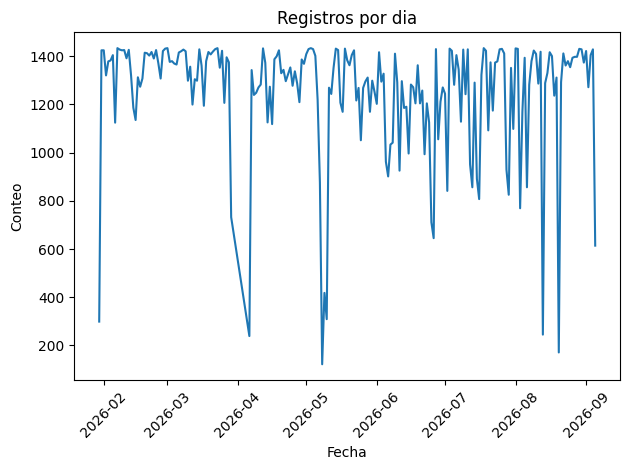

In [7]:
by_day = df.groupby(df['time_index_colombia'].dt.date).size()
fig, ax = plt.subplots()
ax.plot(by_day.index, by_day.values)
ax.set_xlabel('Fecha')
ax.set_ylabel('Conteo')
ax.set_title('Registros por dia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Celda B — Registros por hora del día**

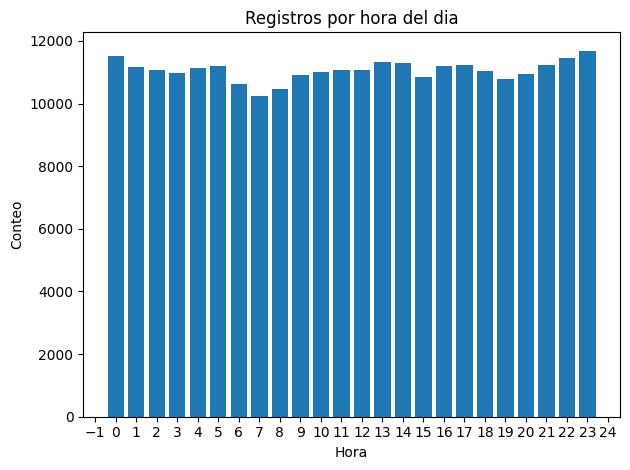

In [8]:
by_hour = df.groupby(df['time_index_colombia'].dt.hour).size()
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values)
ax.set_xlabel('Hora')
ax.set_ylabel('Conteo')
ax.set_title('Registros por hora del dia')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

**Celda C — Registros por entity_id**

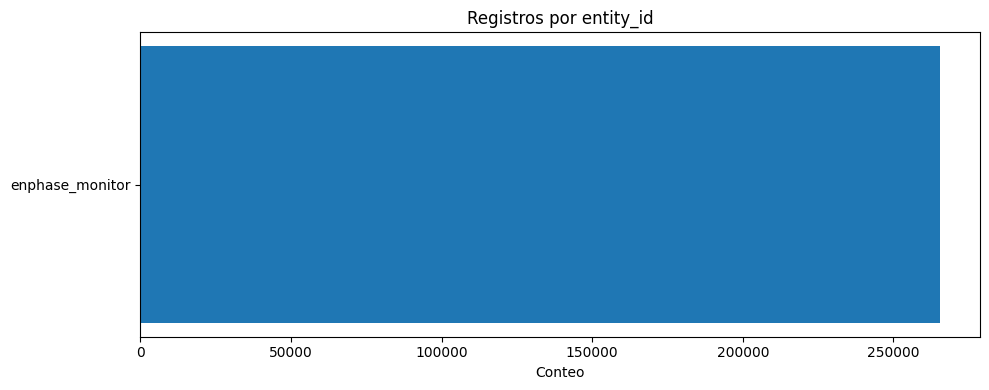

In [9]:
by_entity = df['entity_id'].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, len(by_entity) * 0.3)))
ax.barh(by_entity.index.astype(str), by_entity.values)
ax.set_xlabel('Conteo')
ax.set_title('Registros por entity_id')
plt.tight_layout()
plt.show()

### 3.3 — Distribución de `energyproducedtoday`

**energyproducedtoday — histograma**

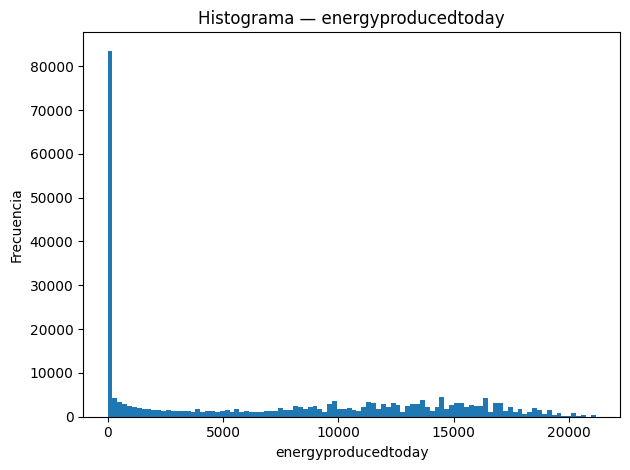

In [10]:
fig, ax = plt.subplots()
ax.hist(df['energyproducedtoday'].dropna(), bins=100)
ax.set_xlabel('energyproducedtoday')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — energyproducedtoday')
plt.tight_layout()
plt.show()

**energyproducedtoday — boxplot**

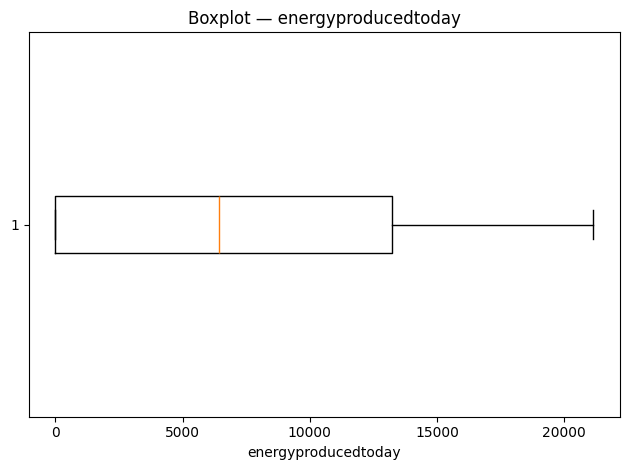

In [11]:
fig, ax = plt.subplots()
ax.boxplot(df['energyproducedtoday'].dropna(), vert=False)
ax.set_xlabel('energyproducedtoday')
ax.set_title('Boxplot — energyproducedtoday')
plt.tight_layout()
plt.show()

### 3.4 — Evidencia del reinicio diario del contador

Esta gráfica es la que justifica todo el Bloque 5. El contador **no es acumulado de por
vida**: dibuja un diente de sierra, sube durante las horas de sol y vuelve a cero en el
siguiente ciclo.

De ahí salen las dos reglas del resample:

- **No se promedia.** La media de un contador no representa ninguna magnitud física.
- **Un delta negativo no se anula.** Ocurre una vez por ciclo y es esperado; la energía de
  esa hora es lo acumulado desde el reinicio, es decir el valor actual del contador.

La segunda celda mide **a qué hora exacta cae el reinicio**. No es un detalle: determina
cómo hay que validar el resultado en el 5.3.

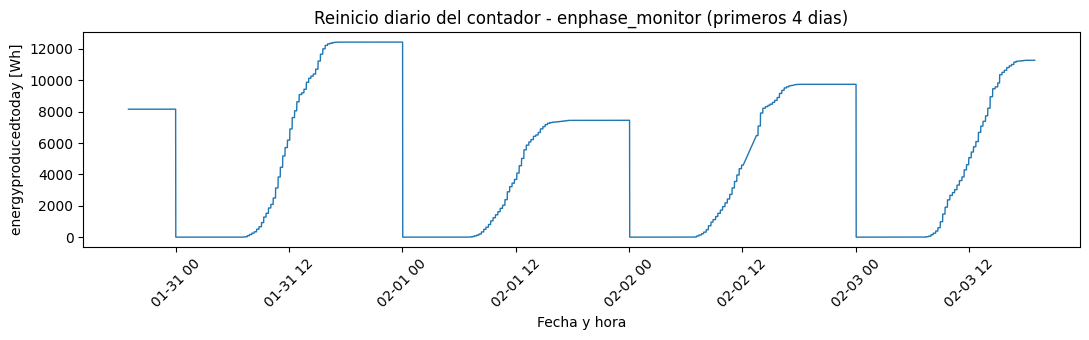

In [12]:
## Se toman los primeros días de la serie, que es donde el patrón se ve sin hacer zoom.
muestra = df.sort_values('time_index_colombia')
ini = muestra['time_index_colombia'].min()
vent = muestra[muestra['time_index_colombia'] < ini + pd.Timedelta(days=4)]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(vent['time_index_colombia'], vent['energyproducedtoday'], lw=1)
ax.set_xlabel('Fecha y hora')
ax.set_ylabel('energyproducedtoday [Wh]')
ax.set_title('Reinicio diario del contador - enphase_monitor (primeros 4 dias)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
## ¿A qué hora reinicia? El resultado condiciona el 5.3.
_ord = df.sort_values(['entity_id', 'time_index_colombia'])
_neg = _ord.groupby('entity_id', observed=True)['energyproducedtoday'].diff() < 0
print('Reinicios detectados:', int(_neg.sum()))
print()
print('Hora del dia en que cae el reinicio:')
print(_ord[_neg]['time_index_colombia'].dt.hour.value_counts().sort_index())
print()
print('Minuto exacto (dentro de la hora 0):')
_h0 = _ord[_neg & (_ord['time_index_colombia'].dt.hour == 0)]
print(_h0['time_index_colombia'].dt.minute.value_counts().sort_index().head())

Reinicios detectados: 211

Hora del dia en que cae el reinicio:
time_index_colombia
0     204
1       3
9       2
15      1
22      1
Name: count, dtype: int64

Minuto exacto (dentro de la hora 0):
time_index_colombia
0     9
1    41
2    53
3    32
4    32
Name: count, dtype: int64


## Bloque 4 — Limpieza de atípicos

### 4.1 — Conversión a numéricos

In [14]:
# Se repite la conversión del Bloque 2 para poder correr la limpieza sola,
# sin tener que volver a ejecutar todo el notebook desde el inicio
for col in num_cols + aux_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### 4.2 — Validación de rangos físicos y descarte de lecturas corruptas

Dos filtros distintos, por dos motivos distintos:

1. **Rango físico** sobre `energyproducedtoday`, igual que en los demás notebooks.
2. **Lecturas corruptas**, que son propias de esta fuente. Hay muestras sueltas donde
   *todos* los campos caen a cero a la vez, con las lecturas vecinas normales. Un
   `energyproducedlifetime` de 0 en un sistema comisionado en octubre de 2013 es
   físicamente imposible, así que sirve de testigo para detectarlas.

La segunda es la que importa: un cero espurio en pleno día parecería un reinicio del
contador y le inyectaría energía falsa a esa hora.

In [15]:
print('NaNs antes:')
print(df[num_cols + aux_cols].isna().sum())

## Energía producida en el día por el arreglo completo, en Wh. El tope de 50.000 Wh
## se fija sobre los 4,9 kWp instalados: ni en el mejor día tropical un sistema así
## entrega más de ~35 kWh. El máximo real observado en la serie es 21.142 Wh, así que
## el filtro no toca ningún dato válido y sí atraparía un centinela de desborde de entero.
RANGES = {
    'energyproducedtoday': (0, 50_000),
}

## Lo que queda fuera de rango no se borra aquí: se marca como NaN.
## La fila completa recién se elimina en el 4.3.
for col, (lo, hi) in RANGES.items():
    df[col] = df[col].where(df[col].between(lo, hi))

## Lecturas corruptas: el contador de por vida no puede valer 0 en un sistema de 2013.
## Se anula la fila entera (no solo ese campo) porque el fallo afecta a toda la muestra.
corruptas = df['energyproducedlifetime'] <= 0
print()
print(f'Lecturas corruptas detectadas (energyproducedlifetime = 0): {int(corruptas.sum())}')
if corruptas.any():
    print(df.loc[corruptas, ['time_index_colombia', 'energyproducedtoday', 'energyproducedlifetime']].to_string(index=False))
df.loc[corruptas, num_cols] = np.nan

print()
print('NaNs despues:')
print(df[num_cols].isna().sum())

NaNs antes:
energyproducedtoday       0
energyproducedlifetime    0
dtype: int64

Lecturas corruptas detectadas (energyproducedlifetime = 0): 3
time_index_colombia  energyproducedtoday  energyproducedlifetime
2026-03-22 04:43:53                    0                       0
2026-06-04 22:09:17                    0                       0
2026-06-04 22:10:18                    0                       0

NaNs despues:
energyproducedtoday    3
dtype: int64


### 4.3 — Eliminación de filas sin información esencial

In [16]:
## Cae la fila entera si le falta cualquier columna esencial: tanto los vacíos que ya
## venían del origen como los valores que quedaron fuera de rango o corruptos en el 4.2.
## El auxiliar energyproducedlifetime ya cumplió su función y se descarta aquí.
before = len(df)
df = df.dropna(subset=num_cols).drop(columns=aux_cols)
print(f'Filas eliminadas: {before - len(df)}  — shape resultante: {df.shape}')

Filas eliminadas: 3  — shape resultante: (265450, 3)


## Bloque 5 — Resample horario: energía incremental con regla de reinicio diario

`energyproducedtoday` es un contador **diario**, así que el Bloque 5 no promedia: toma el
último valor de cada hora y calcula la energía de esa hora a partir de la diferencia con
la hora anterior.

- **5.1** — valor del contador al **cierre de cada hora** (`last`) + nº de muestras crudas (`n_muestras`).
- **5.2** — **energía horaria** con la regla del reinicio + banderas de calidad (`gap_h`, `calidad`).
- **5.3** — validación contra el total de cada ciclo de reinicio.

In [17]:
## Este FREQ nos permite cambiar la frecuencia de resampleo de
## los datos, dependiendo de lo que requieran los Indicadores o KPIs
FREQ = '60min'

## Tolerancia de hueco: con FREQ='60min', dos horas contiguas están a 1 h de distancia.
## Si se cambia el FREQ hay que ajustar este umbral en la misma unidad (horas).
GAP_MAX_H = 1   # horas contiguas = 'ok'; un salto mayor marca 'hueco'

# 5.1 — Contador al cierre de cada hora ('last', NO 'mean') y cobertura cruda por hora
## Se usa 'last' porque la variable es un contador: el promedio de un acumulado no
## representa nada físico, pero su último valor sí es el estado del monitor al
## cerrar la hora.
grp = df.set_index('time_index_colombia').groupby('entity_id', observed=True).resample(FREQ)
hourly = grp[num_cols].last()
hourly['n_muestras'] = grp.size()            # nº de lecturas crudas que cayeron en la hora
hourly = hourly.reset_index()

## El resample crea intervalos vacíos donde el monitor no reportó nada.
## Aquí se descartan: n_muestras == 0 significa hora sin ninguna lectura cruda.
# Solo horas con dato real (no se fabrican horas vacías)
hourly = hourly[hourly['n_muestras'] > 0].copy()

print('Horas con dato por entidad:')
print(hourly.groupby('entity_id', observed=True).size())

Horas con dato por entidad:
entity_id
enphase_monitor    4726
dtype: int64


In [18]:
# 5.2 — Energía por hora, con la regla del reinicio diario
## Se ordena por entidad y tiempo porque el diff() de abajo depende del orden de las filas;
## el groupby evita que la energía de una entidad se calcule contra la de otra.
df_h = hourly.sort_values(['entity_id', 'time_index_colombia']).copy()
gb = df_h.groupby('entity_id', observed=True)

# Separación (en horas) respecto a la hora-con-dato previa; 1.0 = contigua
df_h['gap_h'] = gb['time_index_colombia'].diff().dt.total_seconds() / 3600

for c in num_cols:
    d = gb[c].diff()

    ## Como el contador es diario, que baje no es corrupción: es el reinicio del ciclo.
    ## En esa hora la energía producida es lo que el contador lleva acumulado desde que
    ## se reinició, o sea su valor actual. Anular el dato borraría producción real.
    df_h['reinicio'] = d < 0
    df_h[c + '_delta'] = np.where(df_h['reinicio'], df_h[c], d)

# Banderas de calidad. No se borra ninguna fila: se marca, y quien calcule el
# indicador decide si la usa.
##   inicio -> primera hora de la serie, no hay delta calculable
##   hueco  -> la energía atraviesa un vacío: la suma del período sigue siendo correcta,
##             pero esa hora no representa una hora real y no sirve para perfiles horarios
##   ok     -> hora contigua a la anterior
##
## `reinicio` va como columna aparte y no como un cuarto valor de `calidad` para que un
## 'hueco' no pueda taparlo, y para que `calidad` conserve los mismos tres valores que
## el resto de notebooks de limpieza del proyecto.
df_h['calidad'] = np.where(df_h['gap_h'] <= GAP_MAX_H, 'ok', 'hueco')
df_h.loc[df_h['gap_h'].isna(), 'calidad'] = 'inicio'   # 1ª hora de cada entidad: sin delta

## Se exportan las energías horarias (no los acumulados) más las columnas de calidad,
## que es lo que consumen IND-08, IND-14 y KPI 07.
out_cols = (['entity_id', 'time_index_colombia']
            + [c + '_delta' for c in num_cols]
            + ['n_muestras', 'gap_h', 'calidad', 'reinicio'])
df_resampled = df_h[out_cols]

# Se descartan las filas 'inicio' (delta no calculable)
df_resampled = df_resampled[df_resampled['calidad'] != 'inicio'].reset_index(drop=True)

print('shape:', df_resampled.shape)
print()
print('Distribución de calidad:')
print(df_resampled['calidad'].value_counts())
print()
print('Horas marcadas como reinicio del contador:', int(df_resampled['reinicio'].sum()))
print('% de horas cuya energía atraviesa un hueco:',
      round(100 * (df_resampled['calidad'] == 'hueco').mean(), 1), '%')

shape: (4725, 7)

Distribución de calidad:
calidad
ok       4616
hueco     109
Name: count, dtype: int64

Horas marcadas como reinicio del contador: 210
% de horas cuya energía atraviesa un hueco: 2.3 %


### 5.3 — Validación: suma horaria contra el total de cada ciclo

Prueba independiente de que la regla del reinicio reconstruye bien la energía. Si el
método es correcto, **sumar las energías horarias de un ciclo tiene que dar el mismo total
que el máximo que alcanzó el contador en ese mismo ciclo**.

**Por ciclo de reinicio, no por fecha de calendario.** Esta es la diferencia con el
notebook del Fronius y no es un capricho: aquí el contador reinicia en los primeros minutos
pasada la medianoche (repartidos entre 00:00 y 00:04, con la moda en 00:02), así que el
arranque de cada día calendario todavía arrastra el total del día anterior. Agrupar por
fecha haría que el máximo del día N fuera el total del día N−1, y la validación reportaría
un 56 % de coincidencia sobre un cálculo que en realidad es correcto. Delimitando los
ciclos por el propio reinicio, la comparación queda bien planteada.

> El único ciclo que no coincide es el **ciclo 0**, y es inevitable: la serie empieza el
> 30 de enero a las 20:00, con el contador ya en 8.158 Wh de ese día. Ese primer ciclo está
> truncado por el inicio de la descarga, no por un fallo del método.

In [19]:
## El ciclo se numera con el acumulado de reinicios: cada vez que el contador vuelve
## a cero empieza un ciclo nuevo, sin depender de a qué hora del día caiga.
v = df_h.sort_values(['entity_id', 'time_index_colombia']).copy()
v['ciclo'] = v.groupby('entity_id', observed=True)['reinicio'].cumsum()
v = v[v['calidad'] != 'inicio']

comp = v.groupby(['entity_id', 'ciclo'], observed=True).agg(
    suma_horaria=('energyproducedtoday_delta', 'sum'),
    max_contador=('energyproducedtoday', 'max'),
)
comp = comp[comp['max_contador'] > 0]
comp['dif_pct'] = (comp['suma_horaria'] - comp['max_contador']) / comp['max_contador'] * 100

print(f'Ciclos comparados: {len(comp)}')
print(f"Coinciden dentro del 1%: {(comp['dif_pct'].abs() < 1).mean() * 100:.1f}%")
print()
print('Distribución de la diferencia (%):')
print(comp['dif_pct'].describe().round(3))
print()
print('Ciclos que no coinciden:')
malos = comp[comp['dif_pct'].abs() >= 1]
print(malos.round(1).to_string() if len(malos) else '  ninguno')

Ciclos comparados: 211
Coinciden dentro del 1%: 99.5%

Distribución de la diferencia (%):
count    211.000
mean      -0.474
std        6.884
min     -100.000
25%        0.000
50%        0.000
75%        0.000
max        0.000
Name: dif_pct, dtype: float64

Ciclos que no coinciden:
                       suma_horaria  max_contador  dif_pct
entity_id       ciclo                                     
enphase_monitor 0               0.0        8158.0   -100.0


## Bloque 6 — Exportación

In [20]:
csv_path     = 'clean_etenphaseinverter.csv'
parquet_path = 'clean_etenphaseinverter.parquet'

df_resampled.to_csv(csv_path, index=False)
df_resampled.to_parquet(parquet_path, engine='pyarrow', index=False)

print(f'CSV guardado en:     {csv_path}  — shape: {df_resampled.shape}')
print(f'Parquet guardado en: {parquet_path}  — shape: {df_resampled.shape}')
print()
print('Columnas:', list(df_resampled.columns))
print()
print('Rango temporal:', df_resampled['time_index_colombia'].min(),
      '->', df_resampled['time_index_colombia'].max())
print()
## Contraste final de sanidad: el rendimiento especifico debe caer en el rango
## esperable para Medellin (~3-4 kWh/kWp-dia). Si sale muy fuera, algo se rompio.
_kwh = df_resampled['energyproducedtoday_delta'].sum() / 1000
_dias = df_resampled['time_index_colombia'].dt.date.nunique()
print(f'Energia total: {_kwh:.1f} kWh en {_dias} dias')
print(f'IGS = {_kwh / 4.9 / _dias:.2f} kWh/kWp-dia  (SFV1, 4,9 kWp)')

CSV guardado en:     clean_etenphaseinverter.csv  — shape: (4725, 7)
Parquet guardado en: clean_etenphaseinverter.parquet  — shape: (4725, 7)

Columnas: ['entity_id', 'time_index_colombia', 'energyproducedtoday_delta', 'n_muestras', 'gap_h', 'calidad', 'reinicio']

Rango temporal: 2026-01-30 20:00:00 -> 2026-09-05 10:00:00

Energia total: 2958.7 kWh en 212 dias
IGS = 2.85 kWh/kWp-dia  (SFV1, 4,9 kWp)
